# Quick Test
Check if python is running.

In [157]:
print("Hello from your first notebook!")

Hello from your first notebook!


# Project import

Import the packages that I think I will need.

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the data from file

Let's take the first peek at the data.

In [159]:
df = pd.read_csv("train_data.csv")
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


A function to drop columns that I think won't be needed.

In [160]:
def drop_columns(df, columns):
    """
    Drop one or more columns from a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame from which columns will be removed.

    columns : str or list of str
        The column name or collection of column names to drop.
        Examples:
        - "PassengerId"
        - ["PassengerId", "Cabin", "Ticket"]

    Returns
    -------
    pandas.DataFrame
        A new DataFrame with the specified columns removed.

    Raises
    ------
    TypeError
        If `columns` is not a string, list, tuple, or set.
    KeyError
        If one or more specified columns do not exist in the DataFrame.

    Examples
    --------
    Drop a single column:
    >>> df = drop_columns(df, "PassengerId")

    Drop multiple columns:
    >>> df = drop_columns(df, ["PassengerId", "Cabin"])

    Notes
    -----
    This function does not modify the original DataFrame in place.
    It returns a new DataFrame.
    """
    if isinstance(columns, str):
        columns = [columns]
    elif not isinstance(columns, (list, tuple, set)):
        raise TypeError("`columns` must be a string, list, tuple, or set of column names.")

    missing_columns = [col for col in columns if col not in df.columns]
    if missing_columns:
        raise KeyError(f"The following columns do not exist in the DataFrame: {missing_columns}")

    return df.drop(columns=list(columns))

A function to convert some columns to boolean flags.

In [161]:
def convert_column_to_boolean(df, column_name, drop_original=True):
    """
    Convert a DataFrame column into a boolean indicator column.

    The new column is named "Has<ColumnName>" and contains:
    - 0 if the original value is NaN or an empty string
    - 1 for any other value

    If the original column contains string values, leading and trailing
    whitespace is removed before evaluating whether the value is empty.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    column_name : str
        The name of the column to convert.
    drop_original : bool, default=True
        If True, remove the original column after creating the boolean column.
        If False, keep the original column.

    Returns
    -------
    pandas.DataFrame
        A new DataFrame with a boolean indicator column named "Has<ColumnName>".

    Raises
    ------
    KeyError
        If `column_name` does not exist in the DataFrame.

    Examples
    --------
    >>> df = convert_column_to_boolean(df, "Cabin")
    >>> df[["HasCabin"]].head()

    >>> df = convert_column_to_boolean(df, "Age", drop_original=False)
    >>> df[["Age", "HasAge"]].head()
    """
    if column_name not in df.columns:
        raise KeyError(f"Column '{column_name}' does not exist in the DataFrame.")

    new_df = df.copy()

    def to_boolean_flag(value):
        if pd.isna(value):
            return 0
        if isinstance(value, str):
            value = value.strip()
            return 0 if value == "" else 1
        return 1

    new_column_name = f"Has{column_name}"
    new_df[new_column_name] = new_df[column_name].apply(to_boolean_flag)

    if drop_original:
        new_df = new_df.drop(columns=[column_name])

    return new_df

Dropping `PassengerId` and `Name` columns because I think they don't any value.

I am a bit torn on what to do with the age.  The number of rows with missing age is too high. On the other hand I think age could be a huge factor that can contribute to survival.

I could drop the ticket column as well as I don't see how I can use it.

In [162]:
# Applying data cleaning

df = drop_columns(df, ["PassengerId", "Name"])
df = convert_column_to_boolean(df, "Cabin")
df = convert_column_to_boolean(df, "Age", drop_original=False)
df["Age"] = df["Age"].fillna(-1)

nan_rows = df[df.isna().any(axis=1)].index
df = df.drop(index=nan_rows)

print(f"Dropped {len(nan_rows)} rows with NaN values.")
df.head()

Dropped 2 rows with NaN values.


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,HasAge
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,1
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,1
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1
3,1,1,female,35.0,1,0,113803,53.1000,S,1,1
4,0,3,male,35.0,0,0,373450,8.0500,S,0,1


EDA utility functions to help me understand the data better.

In [163]:
import pandas as pd
import numpy as np


def summary_statistics(df, columns=None, include_categorical=True):
    """
    Generate summary statistics for a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame to analyze.
    columns : str or list of str, optional
        A column name or list of column names to include.
        If None, all columns are analyzed.
    include_categorical : bool, default=True
        If True, include summary statistics for categorical columns.
        If False, return only numeric summary statistics.

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing summary statistics.

    Raises
    ------
    TypeError
        If `columns` is not None, a string, or a list/tuple of strings.
    KeyError
        If any specified column does not exist in the DataFrame.

    Examples
    --------
    >>> summary_statistics(df)
    >>> summary_statistics(df, columns=["Age", "Fare"])
    >>> summary_statistics(df, include_categorical=False)
    """
    if columns is None:
        selected_df = df
    else:
        if isinstance(columns, str):
            columns = [columns]
        elif not isinstance(columns, (list, tuple)):
            raise TypeError("`columns` must be None, a string, or a list/tuple of strings.")

        missing_columns = [col for col in columns if col not in df.columns]
        if missing_columns:
            raise KeyError(f"These columns do not exist in the DataFrame: {missing_columns}")

        selected_df = df[columns]

    if include_categorical:
        return selected_df.describe(include="all").transpose()

    return selected_df.describe().transpose()


def grouped_or_filtered_view(
    df,
    group_by=None,
    metrics=None,
    filters=None,
    aggfunc="mean"
):
    """
    Create a grouped or filtered view of a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    group_by : str or list of str, optional
        Column name or list of column names to group by.
        If None, only filtering is applied and the filtered DataFrame is returned.
    metrics : str or list of str, optional
        Numeric column name or list of column names to aggregate.
        If None and group_by is provided, all numeric columns are used.
    filters : dict, optional
        Dictionary of filters to apply before grouping.
        Keys are column names and values are filter values.
        Examples:
        - {"Sex": "female"}
        - {"Pclass": 1, "Embarked": "S"}
        - {"Pclass": [1, 2]}  # keeps rows where Pclass is 1 or 2
    aggfunc : str or dict, default="mean"
        Aggregation function to apply when grouping.
        Examples: "mean", "sum", "median", "count"

    Returns
    -------
    pandas.DataFrame
        A filtered DataFrame if `group_by` is None, otherwise a grouped summary.

    Raises
    ------
    KeyError
        If any specified column does not exist in the DataFrame.

    Examples
    --------
    >>> grouped_or_filtered_view(df, filters={"Sex": "female"})
    >>> grouped_or_filtered_view(df, group_by="Pclass", metrics="Fare")
    >>> grouped_or_filtered_view(df, group_by=["Sex", "Pclass"], metrics=["Age", "Fare"])
    >>> grouped_or_filtered_view(df, filters={"Pclass": [1, 2]}, group_by="Sex", metrics="Fare", aggfunc="median")
    """
    result_df = df.copy()

    if filters is not None:
        missing_filter_cols = [col for col in filters if col not in result_df.columns]
        if missing_filter_cols:
            raise KeyError(f"These filter columns do not exist in the DataFrame: {missing_filter_cols}")

        for column, value in filters.items():
            if isinstance(value, (list, tuple, set)):
                result_df = result_df[result_df[column].isin(value)]
            else:
                result_df = result_df[result_df[column] == value]

    if group_by is None:
        return result_df

    if isinstance(group_by, str):
        group_by = [group_by]

    missing_group_cols = [col for col in group_by if col not in result_df.columns]
    if missing_group_cols:
        raise KeyError(f"These group-by columns do not exist in the DataFrame: {missing_group_cols}")

    if metrics is None:
        metrics = result_df.select_dtypes(include=np.number).columns.tolist()
        metrics = [col for col in metrics if col not in group_by]
    elif isinstance(metrics, str):
        metrics = [metrics]

    missing_metric_cols = [col for col in metrics if col not in result_df.columns]
    if missing_metric_cols:
        raise KeyError(f"These metric columns do not exist in the DataFrame: {missing_metric_cols}")

    grouped_df = result_df.groupby(group_by)[metrics].agg(aggfunc)
    return grouped_df.reset_index()


def correlation_checks(df, columns=None, method="pearson"):
    """
    Compute correlations between numeric columns in a DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        The input DataFrame.
    columns : str or list of str, optional
        Numeric column name or list of numeric column names to include.
        If None, all numeric columns are used.
    method : str, default="pearson"
        Correlation method to use.
        Options include:
        - "pearson"
        - "spearman"
        - "kendall"

    Returns
    -------
    pandas.DataFrame
        A correlation matrix for the selected numeric columns.

    Raises
    ------
    TypeError
        If `columns` is not None, a string, or a list/tuple of strings.
    KeyError
        If any specified column does not exist in the DataFrame.
    ValueError
        If fewer than two numeric columns are available for correlation.

    Examples
    --------
    >>> correlation_checks(df)
    >>> correlation_checks(df, columns=["Age", "Fare", "Survived"])
    >>> correlation_checks(df, method="spearman")
    """
    if columns is None:
        selected_df = df.select_dtypes(include=np.number)
    else:
        if isinstance(columns, str):
            columns = [columns]
        elif not isinstance(columns, (list, tuple)):
            raise TypeError("`columns` must be None, a string, or a list/tuple of strings.")

        missing_columns = [col for col in columns if col not in df.columns]
        if missing_columns:
            raise KeyError(f"These columns do not exist in the DataFrame: {missing_columns}")

        selected_df = df[columns].select_dtypes(include=np.number)

    if selected_df.shape[1] < 2:
        raise ValueError("At least two numeric columns are required to compute correlation.")

    return selected_df.corr(method=method)

In [164]:
# 1. Summary statistics
summary_all = summary_statistics(df)
summary_all

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Survived,889.0,NaN,NaN,NaN,0.382452,0.48626,0.0,0.0,0.0,1.0,1.0
Pclass,889.0,NaN,NaN,NaN,2.311586,0.8347,1.0,2.0,3.0,3.0,3.0
Sex,889,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,889.0,NaN,NaN,NaN,23.541249,17.834487,-1.0,6.0,24.0,35.0,80.0
SibSp,889.0,NaN,NaN,NaN,0.524184,1.103705,0.0,0.0,0.0,1.0,8.0
Parch,889.0,NaN,NaN,NaN,0.382452,0.806761,0.0,0.0,0.0,0.0,6.0
Ticket,889,680,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,889.0,NaN,NaN,NaN,32.096681,49.697504,0.0,7.8958,14.4542,31.0,512.3292
Embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HasCabin,889.0,NaN,NaN,NaN,0.227222,0.419273,0.0,0.0,0.0,0.0,1.0


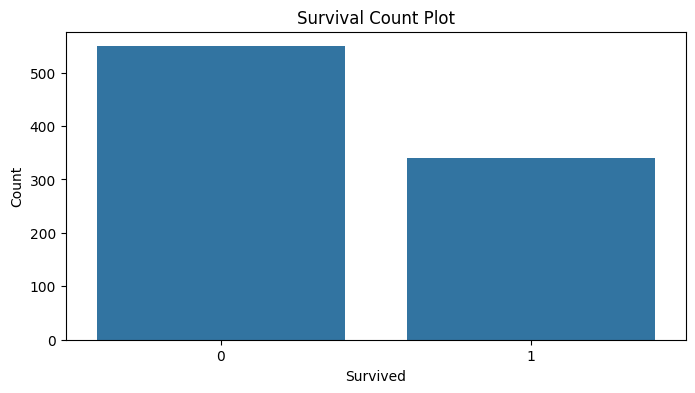

In [165]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Count Plot")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()

The number of passengers who did not survive (Survived = 0) is substantially higher than the number who survived (Survived = 1). 
This indicates that survival was the less common outcome in the dataset, with only about 38% of passengers surviving. 
The plot provides a useful baseline view of the target variable before exploring how survival varied across passenger characteristics.

In [166]:
# Numeric only
summary_numeric = summary_statistics(df, include_categorical=False)
summary_numeric

,count,mean,std,min,25%,50%,75%,max
Survived,889.0,0.382452,0.486260,0.0,0.0000,0.0000,1.0,1.0000
Pclass,889.0,2.311586,0.834700,1.0,2.0000,3.0000,3.0,3.0000
Age,889.0,23.541249,17.834487,-1.0,6.0000,24.0000,35.0,80.0000
SibSp,889.0,0.524184,1.103705,0.0,0.0000,0.0000,1.0,8.0000
Parch,889.0,0.382452,0.806761,0.0,0.0000,0.0000,0.0,6.0000
Fare,889.0,32.096681,49.697504,0.0,7.8958,14.4542,31.0,512.3292
HasCabin,889.0,0.227222,0.419273,0.0,0.0000,0.0000,0.0,1.0000
HasAge,889.0,0.800900,0.399548,0.0,1.0000,1.0000,1.0,1.0000


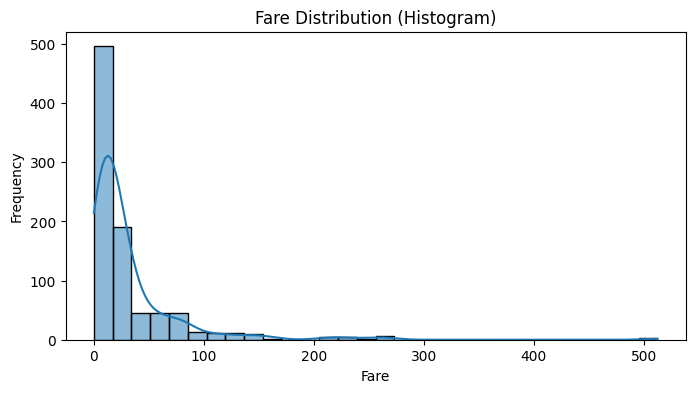

In [167]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="Fare", bins=30, kde=True)
plt.title("Fare Distribution (Histogram)")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

The histogram indicates a heavily right-skewed distribution, with most passengers paying relatively low fares and a small number paying much higher amounts. 
This is supported by the summary statistics, where the mean fare (32.10) is substantially higher than the median fare (14.45), suggesting that a few expensive tickets pull the average upward. 
The result is consistent with the presence of distinct socioeconomic differences among passengers, likely linked to travel class.

In [168]:
# 2. Grouped or filtered views
female_view = grouped_or_filtered_view(df)
female_view.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,HasAge
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S,0,1
1,1,1,female,38.0,1,0,PC 17599,71.2833,C,1,1
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1
3,1,1,female,35.0,1,0,113803,53.1000,S,1,1
4,0,3,male,35.0,0,0,373450,8.0500,S,0,1


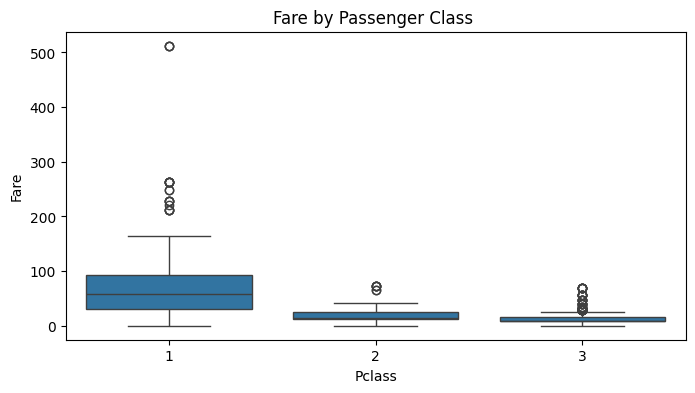

In [169]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=female_view, x="Pclass", y="Fare")
plt.title("Fare by Passenger Class ")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

First-class passengers paid substantially higher fares than second- and third-class passengers, with a much wider spread of values and several extreme outliers. 
In contrast, third-class fares are concentrated at much lower values with less variability. 
This suggests a strong relationship between fare and socioeconomic class, which may help explain why survival patterns also differed across passenger classes.

In [170]:
pclass_grouped = grouped_or_filtered_view(
    df,
    group_by="Pclass",
    metrics=["Age", "Fare", "Survived"],
    aggfunc="mean"
)
pclass_grouped

,Pclass,Age,Fare,Survived
0,1,32.623458,84.193516,0.626168
1,2,28.031685,20.662183,0.472826
2,3,17.900041,13.675550,0.242363


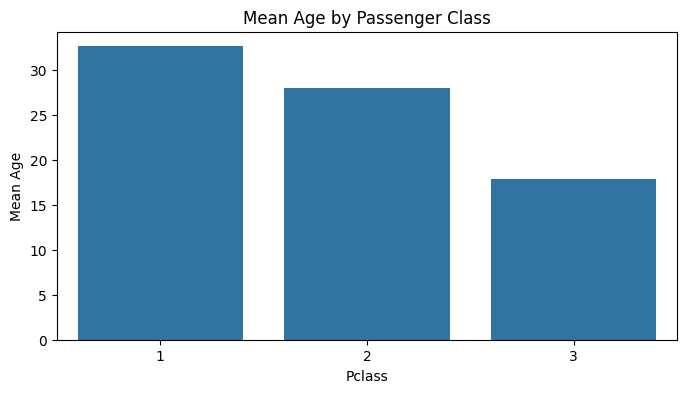

In [171]:
plt.figure(figsize=(8, 4))
sns.barplot(data=pclass_grouped, x="Pclass", y="Age")
plt.title("Mean Age by Passenger Class")
plt.xlabel("Pclass")
plt.ylabel("Mean Age")
plt.show()

First-class passengers had the highest average age, followed by second-class passengers, while third-class passengers were youngest on average. 
This suggests that the social classes differed not only in fare levels but also in demographic composition. 
However, the interpretation should be treated cautiously because missing age values were filled with -1, which may artificially reduce the calculated means.

In [172]:
sex_pclass_embarked_grouped = grouped_or_filtered_view(
    df,
    group_by=["Sex", "Pclass"],
    metrics="Survived",
    aggfunc="mean"
)
sex_pclass_embarked_grouped

,Sex,Pclass,Survived
0,female,1,0.967391
1,female,2,0.921053
2,female,3,0.500000
3,male,1,0.368852
4,male,2,0.157407
5,male,3,0.135447


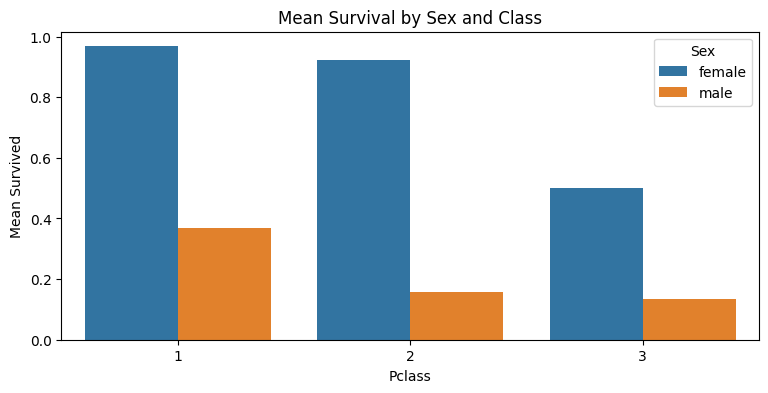

In [173]:
plt.figure(figsize=(9, 4))
sns.barplot(data=sex_pclass_embarked_grouped, x="Pclass", y="Survived", hue="Sex")
plt.title("Mean Survival by Sex and Class")
plt.xlabel("Pclass")
plt.ylabel("Mean Survived")
plt.show()

Female passengers had substantially higher survival rates than male passengers in every class, with first- and second-class women showing especially high survival. 
Survival rates declined from first to third class for both sexes, indicating that passenger class was also strongly associated with survival. 
Overall, the plot suggests that both gender and socioeconomic status played an important role in determining survival outcomes on the Titanic.

In [174]:
# 3. Correlation checks
corr_all = correlation_checks(df)
corr_all

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,HasAge
Survived,1.000000,-0.335549,0.008265,-0.034040,0.083151,0.255290,0.313435,0.090967
Pclass,-0.335549,1.000000,-0.356560,0.081656,0.016824,-0.548193,-0.723815,-0.171701
Age,0.008265,-0.356560,1.000000,-0.181288,-0.043838,0.133040,0.264169,0.686479
SibSp,-0.034040,0.081656,-0.181288,1.000000,0.414542,0.160887,-0.038657,-0.018436
Parch,0.083151,0.016824,-0.043838,0.414542,1.000000,0.217532,0.039101,0.124701
Fare,0.255290,-0.548193,0.133040,0.160887,0.217532,1.000000,0.480425,0.099761
HasCabin,0.313435,-0.723815,0.264169,-0.038657,0.039101,0.480425,1.000000,0.142636
HasAge,0.090967,-0.171701,0.686479,-0.018436,0.124701,0.099761,0.142636,1.000000


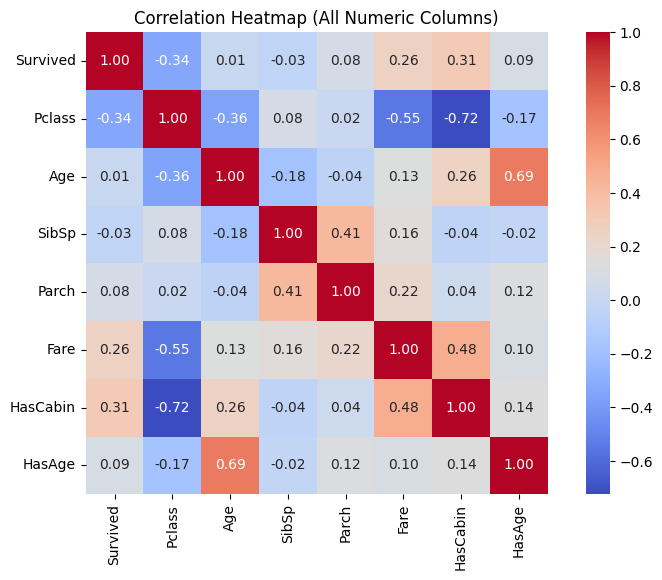

In [175]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_all, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (All Numeric Columns)")
plt.show()

Survival shows the strongest associations with passenger class, fare, and whether cabin information was available. 
In particular, Survived is negatively correlated with Pclass, indicating that lower-class passengers were less likely to survive, while Fare and HasCabin show positive correlations with survival. 
The heatmap also shows strong relationships between Pclass and Fare, and between Pclass and HasCabin, suggesting that these variables may all reflect underlying socioeconomic differences. 
Age appears to have little linear relationship with survival in this analysis, although that result should be interpreted cautiously because missing age values were replaced with -1.

In [176]:
corr_selected = correlation_checks(df, columns=["Survived", "Age", "Fare", "SibSp", "Parch"])
corr_selected

,Survived,Age,Fare,SibSp,Parch
Survived,1.000000,0.008265,0.255290,-0.034040,0.083151
Age,0.008265,1.000000,0.133040,-0.181288,-0.043838
Fare,0.255290,0.133040,1.000000,0.160887,0.217532
SibSp,-0.034040,-0.181288,0.160887,1.000000,0.414542
Parch,0.083151,-0.043838,0.217532,0.414542,1.000000


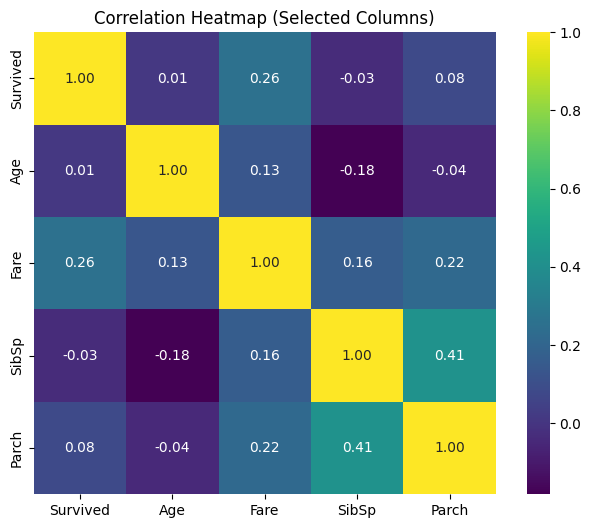

In [177]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_selected, annot=True, cmap="viridis", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Selected Columns)")
plt.show()

Among these variables, fare shows the clearest positive relationship with survival, suggesting that passengers who paid higher fares were somewhat more likely to survive. 
Age, siblings/spouses aboard, and parents/children aboard show only weak linear relationships with survival in this analysis. 
The strongest relationship among the explanatory variables is between SibSp and Parch, which likely reflects family members traveling together. 
However, the age-related results should be interpreted carefully because missing age values were replaced with -1, which may affect the correlations.

## Summary and interpretation

The analysis showed that survival on the Titanic was strongly associated with passenger class, fare, sex, and whether cabin information was recorded. First-class passengers had much higher survival rates than third-class passengers, and women survived at much higher rates than men across all classes. Fare and survival were positively related, while passenger class showed a clear negative relationship with survival because lower-class passengers were less likely to survive. One limitation of the data is that missing age values were too many, about 20%, which may distort age-based statistics and correlations. Overall, the dataset reveals clear social and demographic patterns, but some variables would benefit from more careful treatment of missing data.

The fact that gender came out as factor in survival rate is shocking.